# Pipeline d'Entraînement et d'Évaluation des Modèles de Classification
Ce notebook gère le chargement des données, l'entraînement des modèles de Machine Learning (Base et Optimisés par recherche aléatoire), le calcul des prédictions, ainsi que les simulations de profits financiers (Value Bets et mises dynamiques).

In [5]:
import os
import sys

if os.getcwd().endswith('goal_based'):
    os.chdir('../..')
    print(f"Répertoire de travail calé sur la racine : {os.getcwd()}")

sys.path.append(os.path.abspath('code'))

import config as conf

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import randint, uniform
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, brier_score_loss, f1_score, log_loss, precision_score)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from tqdm import tqdm
from xgboost import XGBClassifier

import config as conf

## Configuration Générale

In [7]:
DATA_PATH = conf.path_clean_cell
SPLIT_RATIO = 0.8
SEUIL_SECURISE = 0.65
MISE_UNITE = 10

COTES_MAP = {"Hvs": "BWH", "Avs": "BWA", "Dvs": "BWD"}
FEATURES = conf.ft_commune
FEATURES_NN = conf.ft_nn
TARGET_BIN = "Hvs"

os.makedirs("models", exist_ok=True)

## Chargement et Préparation des Données

In [9]:

df = pd.read_csv("../"+DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

split_idx = int(len(df) * SPLIT_RATIO)
df_train = df.iloc[:split_idx].copy()
df_test = df.iloc[split_idx:].copy()

X_train_brut = df_train[FEATURES]
X_test_brut = df_test[FEATURES]
X_train_brut_nn = df_train[FEATURES_NN]
X_test_brut_nn = df_test[FEATURES_NN]

y_train = df_train[TARGET_BIN].values
y_test = df_test[TARGET_BIN].values

cote_colonne = COTES_MAP.get(TARGET_BIN, "AvgH")
cotes_test = df_test[cote_colonne].fillna(2.0).values

scaler = StandardScaler()
X_train_nn = scaler.fit_transform(X_train_brut_nn)
X_test_nn = scaler.transform(X_test_brut_nn)

X_train_commune = X_train_brut.values
X_test_commune = X_test_brut.values

## Définition des Modèles et des Grilles d'Hyperparamètres

In [10]:
modeles_base = {
    "LogisticRegression_Base": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost_Base": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "SVM_RBF_base": SVC(probability=True, kernel='rbf', random_state=42),
    "LightGBM_Base": lgb.LGBMClassifier(random_state=42, verbose=-1),
    "MLP_Base": MLPClassifier(max_iter=500, random_state=42)
}

param_grids = {
    "LogisticRegression_Optimisé": (
        LogisticRegression(max_iter=2000, random_state=42),
        {'C': uniform(0.01, 10), 'penalty': ['l2']}
    ),
    "RandomForest_optimisé": (
        RandomForestClassifier(random_state=42),
        {
            'n_estimators': randint(50, 300),
            'max_depth': [None, 5, 10, 20],
            'min_samples_split': randint(2, 11),
            'min_samples_leaf': randint(1, 11)
        }
    ),
    "XGBoost_Optimisé": (
        XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        {
            'n_estimators': randint(50, 250),
            'max_depth': randint(3, 8),
            'learning_rate': uniform(0.01, 0.2),
            'subsample': uniform(0.6, 0.4)
        }
    ),
    "SVM_RBF_Optimisé": (
        SVC(probability=True, kernel='rbf', random_state=42),
        {'C': uniform(0.1, 10), 'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]}
    ),
    "LightGBM_Optimisé": (
        lgb.LGBMClassifier(random_state=42, verbose=-1),
        {
            'n_estimators': randint(50, 250),
            'max_depth': randint(3, 10),
            'learning_rate': uniform(0.01, 0.2),
            'num_leaves': randint(15, 63)
        }
    ),
    "MLP_Optimisé": (
        MLPClassifier(max_iter=1000, random_state=42),
        {
            'hidden_layer_sizes': [(50,), (100,), (50, 25), (100, 50)],
            'alpha': uniform(1e-5, 1e-2),
            'learning_rate_init': uniform(0.001, 0.01)
        }
    )
}

## Fonctions Utilitaires d'Entraînement et de Sélection

In [11]:
def get_datasets(nom_cle):
    if "MLP" in nom_cle:
        return X_train_nn, X_test_nn
    return X_train_commune, X_test_commune

modeles_entraines = {}
probas_predictions = {}

print("--- ÉTAPE 1 : ENTRAÎNEMENT DES MODÈLES DE BASE ---")
for nom, model in tqdm(modeles_base.items()):
    X_tr, X_te = get_datasets(nom)
    model.fit(X_tr, y_train)
    modeles_entraines[nom] = model
    probas_predictions[nom] = model.predict_proba(X_te)[:, 1]
    joblib.dump(model, f"models/{nom}.pkl")

print("\n--- ÉTAPE 2 : OPTIMISATION VIA RANDOMIZED SEARCH (TIME SERIES SPLIT) ---")
tscv = TimeSeriesSplit(n_splits=3)

for nom, (model, grid) in tqdm(param_grids.items()):
    X_tr, X_te = get_datasets(nom)
    search = RandomizedSearchCV(
        estimator=model, param_distributions=grid, n_iter=10,
        scoring='neg_log_loss', cv=tscv, random_state=42, n_jobs=-1
    )
    search.fit(X_tr, y_train)
    best_mod = search.best_estimator_
    modeles_entraines[nom] = best_mod
    probas_predictions[nom] = best_mod.predict_proba(X_te)[:, 1]
    joblib.dump(best_mod, f"models/{nom}.pkl")

--- ÉTAPE 1 : ENTRAÎNEMENT DES MODÈLES DE BASE ---


  0%|          | 0/6 [00:00<?, ?it/s]D:\MATTH\Etudes\venv_python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
 33%|███▎      | 2/6 [00:08<00:19,  4.82s/it]D:\MATTH\Etudes\venv_python\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:03:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
 67%|██████▋   | 4/6 [03:15<02:30, 75.28s/it]D:\MATTH


--- ÉTAPE 2 : OPTIMISATION VIA RANDOMIZED SEARCH (TIME SERIES SPLIT) ---


  0%|          | 0/6 [00:00<?, ?it/s]D:\MATTH\Etudes\venv_python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
 33%|███▎      | 2/6 [02:25<04:55, 73.76s/it]D:\MATTH\Etudes\venv_python\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:09:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
 67%|██████▋   | 4/6 [22:02<16:15, 487.80s/it]D:\MATT

## Intégration de la Baseline Stratégique

In [12]:
probas_predictions["Baseline (Toujours 1)"] = np.full(len(y_test), 1.0 - 1e-15)

## Simulation Financière & Stratégies de Mise

In [13]:
def simuler_profits_complets(probas, cotes, y_true, seuil_opt):
    prob_bk = 1.0 / cotes
    
    # 1. Stratégie Standard (Seuil Fixe 0.50)
    mask_std = (probas >= 0.50)
    gains_std = np.where(mask_std & (y_true == 1), MISE_UNITE * cotes, 0.0)
    mises_std = np.where(mask_std, MISE_UNITE, 0.0)
    profits_std = np.cumsum(gains_std - mises_std)
    
    # 2. Stratégie Sécurisée (Seuil Optimal Concret)
    mask_sec = (probas >= seuil_opt)
    gains_sec = np.where(mask_sec & (y_true == 1), MISE_UNITE * cotes, 0.0)
    mises_sec = np.where(mask_sec, MISE_UNITE, 0.0)
    profits_sec = np.cumsum(gains_sec - mises_sec)
    
    # 3. Stratégie Dynamique Combinée (Value Bet + Palier de Seuil)
    is_value = (probas > prob_bk)
    mises_dyn = np.zeros(len(probas))
    mises_dyn[(probas >= seuil_opt) & (probas < seuil_opt + 0.10) & is_value] = 10.0
    mises_dyn[(probas >= seuil_opt + 0.10) & is_value] = 30.0
    
    gains_dyn = np.where((mises_dyn > 0) & (y_true == 1), mises_dyn * cotes, 0.0)
    profits_dyn = np.cumsum(gains_dyn - mises_dyn)
    
    return profits_std, profits_sec, profits_dyn

def optimiser_seuil_financier(probas, cotes, y_true):
    seuils_test = np.linspace(0.40, 0.85, 46)
    meilleur_seuil = 0.50
    max_profit = -99999
    
    for s in seuils_test:
        mask = (probas >= s)
        if mask.sum() < 5:
            continue
        profit = (np.where(mask & (y_true == 1), MISE_UNITE * cotes, 0.0) - np.where(mask, MISE_UNITE, 0.0)).sum()
        if profit > max_profit:
            max_profit = profit
            meilleur_seuil = s
            
    return round(meilleur_seuil, 2)

## Calcul du Bilan Global des Métriques & Profits

In [14]:
seuils_optimaux = {}
for nom, probas in probas_predictions.items():
    if nom == "Baseline (Toujours 1)":
        seuils_optimaux[nom] = 1.0
    else:
        seuils_optimaux[nom] = optimiser_seuil_financier(probas, cotes_test, y_test)

bilan_data = []
profits_modeles_base = {"Stratégie Standard (0.50)": {}, "Stratégie Seuil Fixe (€)": {}, "Stratégie Dynamique (€)": {}}
profits_modeles_opti = {"Stratégie Standard (0.50)": {}, "Stratégie Seuil Fixe (€)": {}, "Stratégie Dynamique (€)": {}}

for nom, probas in probas_predictions.items():
    s_opt = seuils_optimaux[nom]
    p_std, p_sec, p_dyn = simuler_profits_complets(probas, cotes_test, y_test, s_opt)
    
    is_opti = "Optimisé" in nom or "optimisé" in nom
    cible_dict = profits_modeles_opti if (is_opti or "Baseline" in nom) else profits_modeles_base
    
    cible_dict["Stratégie Standard (0.50)"][nom] = p_std
    cible_dict["Stratégie Seuil Fixe (€)"][nom] = p_sec
    cible_dict["Stratégie Dynamique (€)"][nom] = p_dyn
    
    p_c = np.clip(probas, 1e-15, 1 - 1e-15)
    preds_std = (probas >= 0.50).astype(int)
    
    bilan_data.append({
        "Modèle": nom,
        "Seuil Opti": s_opt,
        "Log-Loss": round(log_loss(y_test, p_c), 4),
        "Brier Score": round(brier_score_loss(y_test, probas), 4),
        "Accuracy (0.5)": round(accuracy_score(y_test, preds_std), 3),
        "F1-Score (0.5)": round(f1_score(y_test, preds_std, zero_division=0), 3),
        "Précision (0.5)": round(precision_score(y_test, preds_std, zero_division=0), 3),
        "Profit Final Dyn (€)": round(p_dyn[-1], 1)
    })

df_bilan = pd.DataFrame(bilan_data)
print("\n" + "="*110)
print("                                 TABLEAU SYNTHÉTIQUE DES MODÈLES")
print("="*110)
print(df_bilan.to_string(index=False))
print("="*110)


                                 TABLEAU SYNTHÉTIQUE DES MODÈLES
                     Modèle  Seuil Opti  Log-Loss  Brier Score  Accuracy (0.5)  F1-Score (0.5)  Précision (0.5)  Profit Final Dyn (€)
    LogisticRegression_Base        0.63    0.6180       0.2145           0.652           0.585            0.621                 -54.6
               RandomForest        0.69    0.6364       0.2216           0.651           0.586            0.618                  82.5
               XGBoost_Base        0.65    0.6794       0.2357           0.625           0.562            0.583                -197.6
               SVM_RBF_base        0.59    0.6240       0.2164           0.656           0.566            0.644                  -2.1
              LightGBM_Base        0.63    0.6300       0.2190           0.655           0.587            0.627                -196.4
                   MLP_Base        0.78    0.6359       0.2220           0.641           0.553            0.618                 -6

## Visualisation 1 : Modèles de Base (Gammes Initiales)

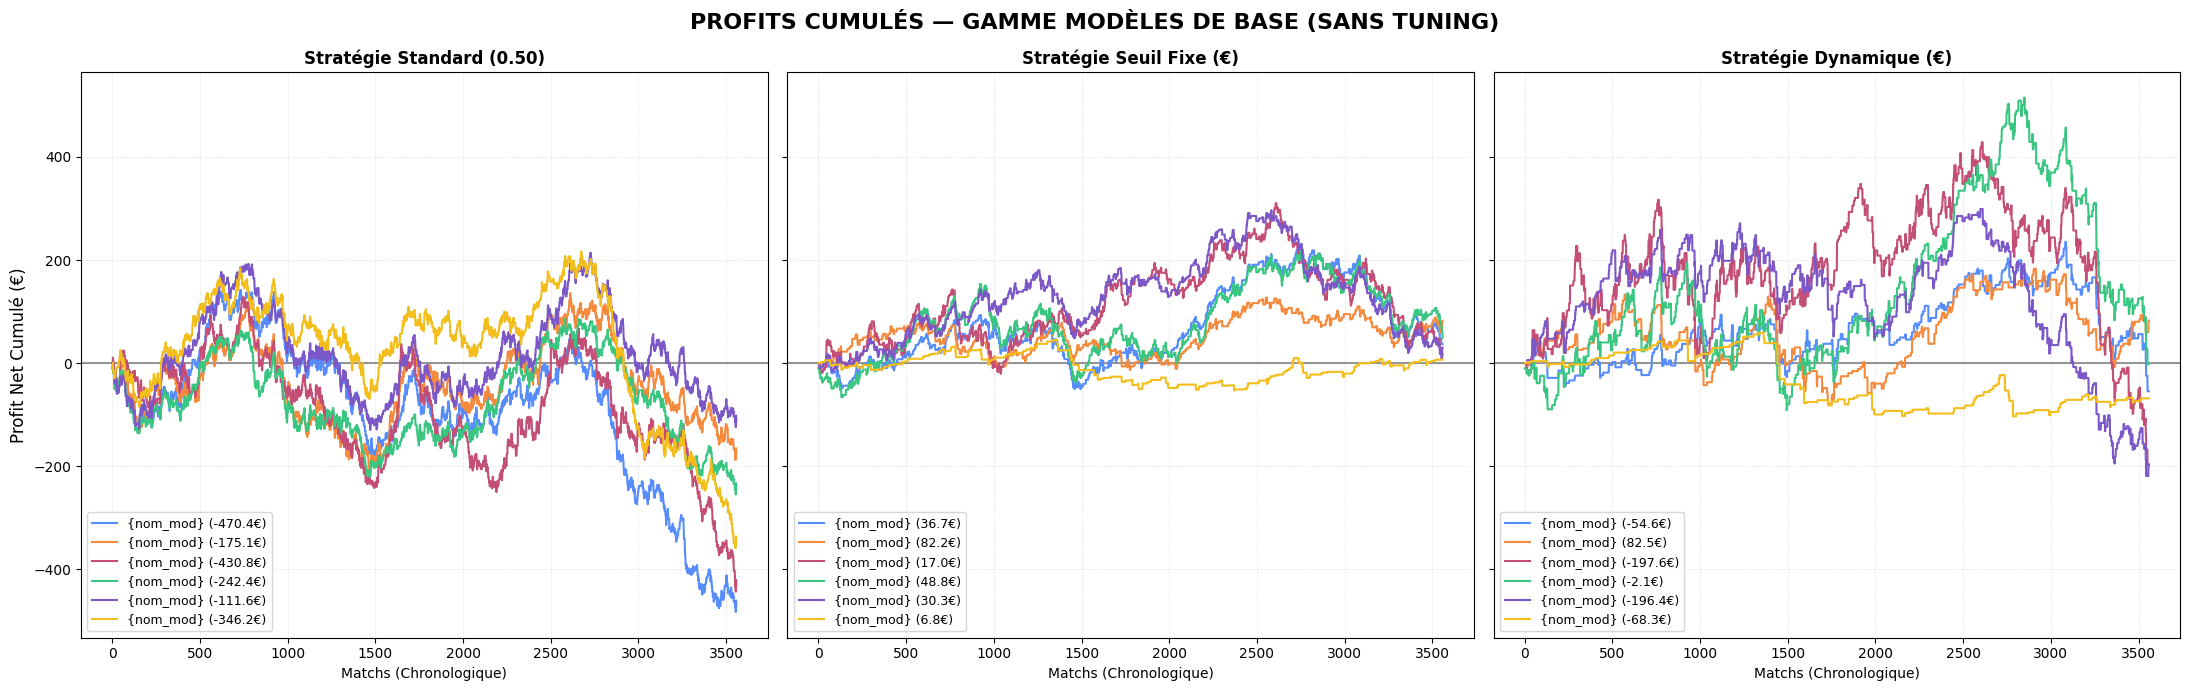

In [15]:
index_matchs = np.arange(1, len(y_test) + 1)

fig1, axs1 = plt.subplots(1, 3, figsize=(22, 7), sharey=True)
fig1.suptitle("PROFITS CUMULÉS — GAMME MODÈLES DE BASE (SANS TUNING)", fontsize=16, fontweight="bold")

for ax, (nom_strat, liste_modeles) in zip(axs1, profits_modeles_base.items()):
    ax.axhline(y=0, color="black", linestyle="-", alpha=0.4)
    for nom_mod, profit_serie in liste_modeles.items():
        is_bl = nom_mod.startswith("Baseline")
        style = {"linestyle": "--", "linewidth": 2.0, "color": "red"} if is_bl else {"linewidth": 1.5}
        ax.plot(index_matchs, profit_serie, label=f"{{nom_mod}} ({profit_serie[-1]:.1f}€)", **style)
        
    ax.set_title(nom_strat, fontsize=12, fontweight="bold")
    ax.set_xlabel("Matchs (Chronologique)")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="lower left", fontsize=9)

axs1[0].set_ylabel("Profit Net Cumulé (€)", fontsize=12)
plt.tight_layout()
plt.show()

## Visualisation 2 : Modèles Optimisés (Random Search)

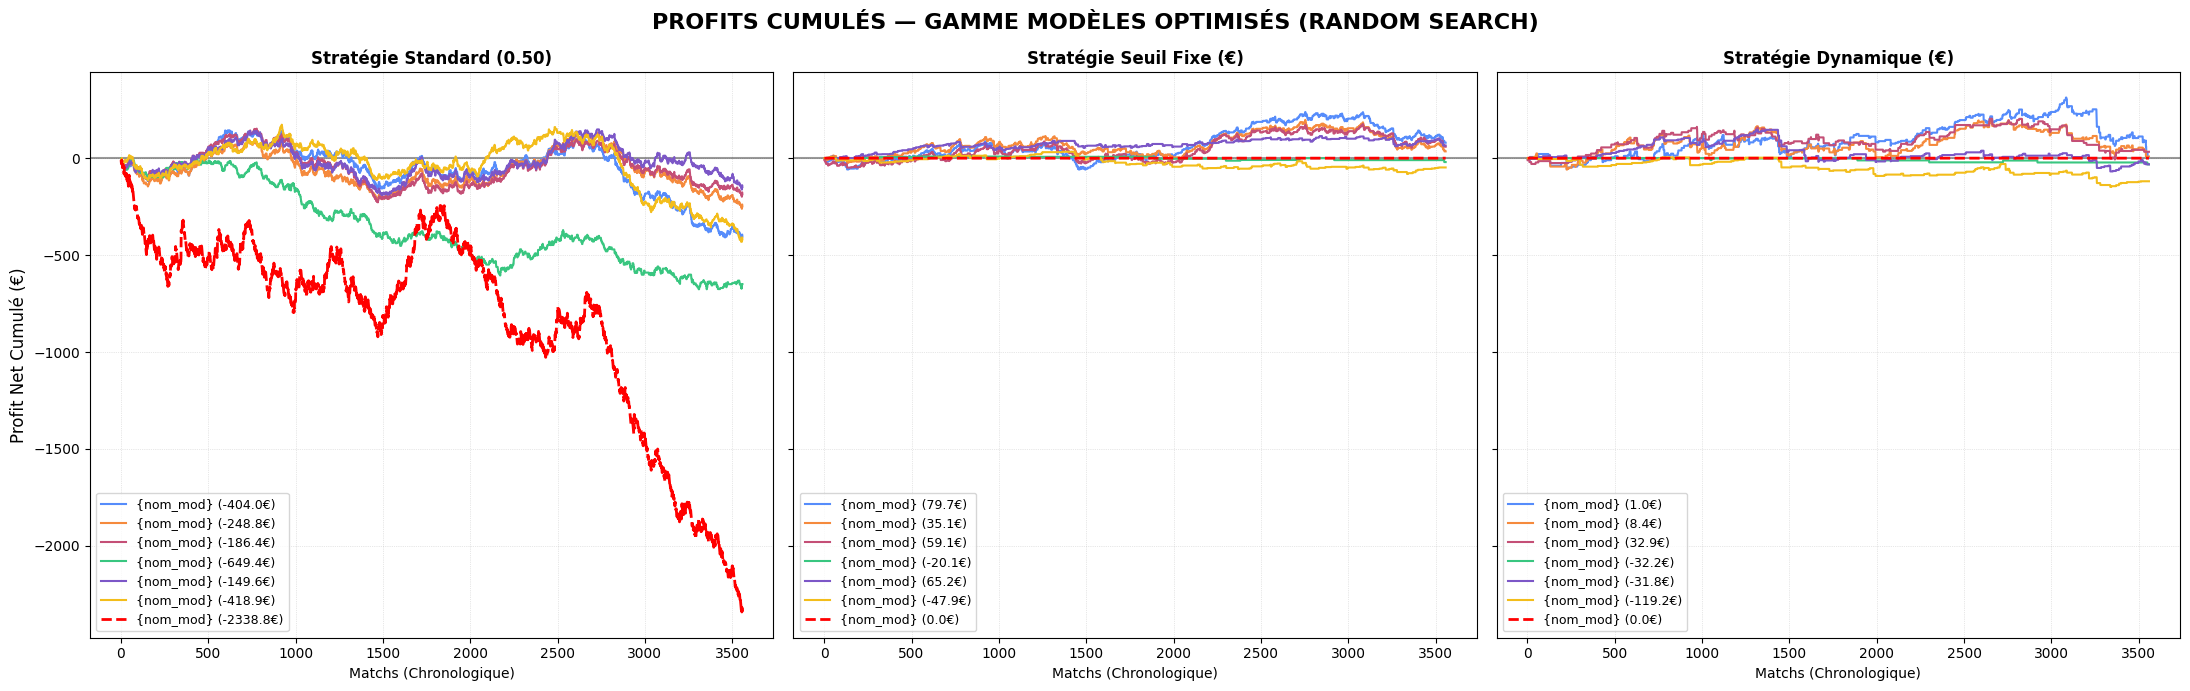

In [16]:
fig2, axs2 = plt.subplots(1, 3, figsize=(22, 7), sharey=True)
fig2.suptitle("PROFITS CUMULÉS — GAMME MODÈLES OPTIMISÉS (RANDOM SEARCH)", fontsize=16, fontweight="bold")

for ax, (nom_strat, liste_modeles) in zip(axs2, profits_modeles_opti.items()):
    ax.axhline(y=0, color="black", linestyle="-", alpha=0.4)
    for nom_mod, profit_serie in liste_modeles.items():
        is_bl = nom_mod.startswith("Baseline")
        style = {"linestyle": "--", "linewidth": 2.0, "color": "red"} if is_bl else {"linewidth": 1.5}
        ax.plot(index_matchs, profit_serie, label=f"{{nom_mod}} ({profit_serie[-1]:.1f}€)", **style)
        
    ax.set_title(nom_strat, fontsize=12, fontweight="bold")
    ax.set_xlabel("Matchs (Chronologique)")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="lower left", fontsize=9)

axs2[0].set_ylabel("Profit Net Cumulé (€)", fontsize=12)
plt.tight_layout()
plt.show()